# Exercise 4

We are given the damped driven oscillator equation of motion,
$$\ddot{x} + 2\beta \dot{x} + \omega_0^2x = f(t)$$
where $f(t) = f_0\cos(\omega t)$.

### 4a.)

Modify the code (or write your own) and include a driving force $f(t) = f_0\cos(\omega t)$.
- To start, choose $f_0 = 1$, $\omega_0 = 10$, and $\beta = 0.1$.
- Check that your code produces a steady state solution for the driven harmonic oscillator. Roughly, what is the steady state amplitude $A(t\rightarrow\infty)$ of the driven oscillator?

We will create our own code for this.
Importantly, we note
$$\dot{v} = \ddot{x} = f_0\cos(\omega t) - 2\beta v - \omega_0^2 x$$
$$\dot{x} = v$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import UsefulFuncs as uf

In [27]:
def DampedDrivenOscillatorAcc(x,v,t,omega,f0,beta,omega0):
    return f0 * np.cos( omega * t ) - 2 * beta * v - omega0**2 * x
# Create our acceleration function

f_0 = 1
omega_0 = 10
beta = 0.1
#required parameters

x_0 = 1
v_0 = 0
t_0 = 0
t_f = 200
dt = 1/50
omega = 2
#arbitrary intitial conds + parameters

In [28]:
def RK2O_t_dep(x_0,v_0,t_0,tf,dt,acc_func=uf.SHO_acc,fargs=tuple|None):
    #mostly copied from RK2O_gen()
    t = np.arange(t_0, tf, dt)
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    x[0], v[0] = x_0,v_0
    
    for i in range(1,len(t)):
        x_prev = x[i-1]
        v_prev = v[i-1]

        k_1x = v_prev * dt
        try:
            k_1v = dt * acc_func(x_prev,v_prev,t[i],*fargs) #use current time as a parameter. This only works for driven functions.
        except:
            k_1v = dt * acc_func(x_prev,v_prev)
            print("An error occured. \nRunge-Kutta step 1 was not able to assign t_value or fargs value to acceleration function.")
        k_2x = dt * (v_prev + k_1v)
        try:
            k_2v = dt * (acc_func(x_prev+k_1x,v_prev+k_1v,t[i],*fargs)) #same as before
        except:
            k_2v = dt * (acc_func(x_prev+k_1x,v_prev+k_1v))
            print("An error occured. \nRunge-Kutta step 2 was not able to assign t_value or fargs value to acceleration function.")
        x[i] = x_prev + 0.5 * (k_1x+k_2x)
        v[i] = v_prev + 0.5 * (k_1v+k_2v)
    return t,x,v

In [29]:
fargs_1 = (omega,f_0,beta,omega_0)
t,x,v = RK2O_t_dep(x_0,v_0,t_0,t_f,dt,DampedDrivenOscillatorAcc,fargs_1)
DDO_df = pd.DataFrame({'t':t,'x':x,'v':v})

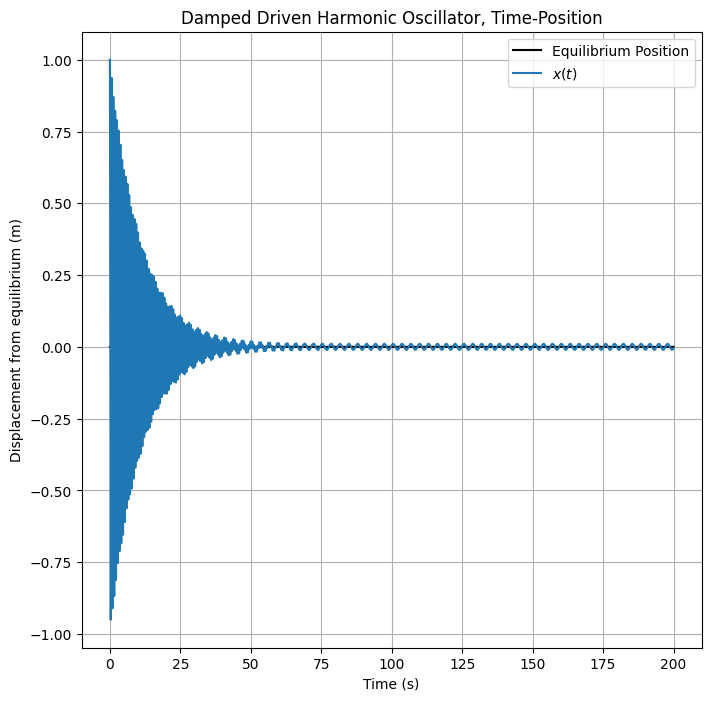

In [30]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(DDO_df['t'],np.zeros(t.shape),color="black",label="Equilibrium Position")
ax.plot(DDO_df['t'],DDO_df['x'],label=r"$x(t)$")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement from equilibrium (m)")
ax.set_title("Damped Driven Harmonic Oscillator, Time-Position")
ax.grid()
ax.legend()
plt.show()

We see that the amplitude converges to a specific, singular amplitude. We evaluate this from the data;

In [31]:
finalA = np.max(DDO_df['x'][8000:])
print(r"The amplitude that x(t) converges to is",f"{finalA:.3E} meters.")

The amplitude that x(t) converges to is 1.041E-02 meters.


### 4b.)

For different choices of the driving frequency, $\omega$, observe the behavior of the driven oscillator. Describe the behavior of the driven oscillator for $\omega <<\omega_0$, $\omega\approx\omega_0$, and $\omega >>\omega_0$.

We perform our analysis on a shorter timeframe, while modulating $\omega$. 

We use our first value of $\omega<<\omega_0$, $2 << 10$.

In [32]:
t_f = 75
omega = 2

In [33]:
fargs_1 = (omega,f_0,beta,omega_0)
t,x,v = RK2O_t_dep(x_0,v_0,t_0,t_f,dt,DampedDrivenOscillatorAcc,fargs_1)
DDO_df = pd.DataFrame({'t':t,'x':x,'v':v})

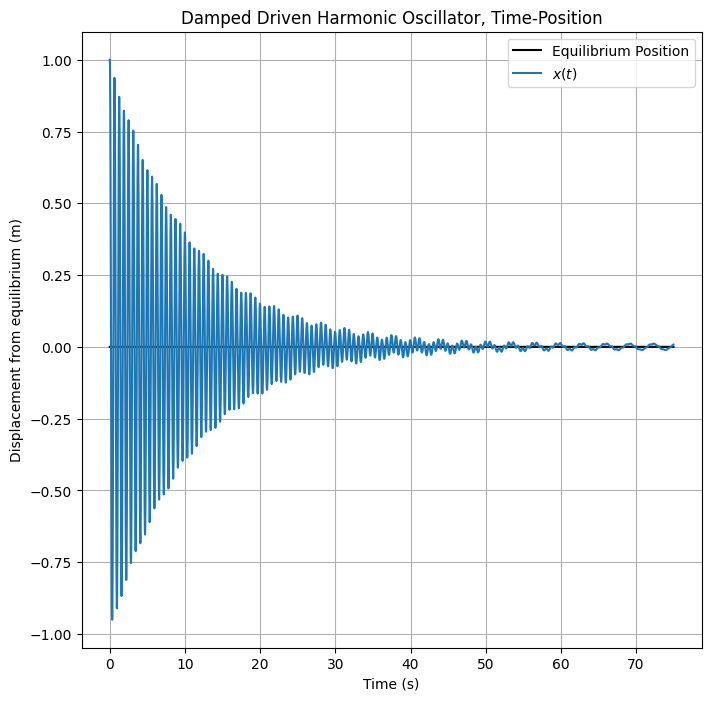

In [34]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(DDO_df['t'],np.zeros(t.shape),color="black",label="Equilibrium Position")
ax.plot(DDO_df['t'],DDO_df['x'],label=r"$x(t)$")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement from equilibrium (m)")
ax.set_title("Damped Driven Harmonic Oscillator, Time-Position")
ax.grid()
ax.legend()
plt.show()

We notice that $x(t)$ has an oscillatory motion, while decreasing in amplitude; i.e. that the oscillator is underdamped.

We now take $\omega = 10 \approx 10 = \omega_0$.

In [49]:
omega = 10
fargs_1 = (omega,f_0,beta,omega_0)
t,x,v = RK2O_t_dep(x_0,v_0,t_0,t_f,dt,DampedDrivenOscillatorAcc,fargs_1)
DDO_df = pd.DataFrame({'t':t,'x':x,'v':v})

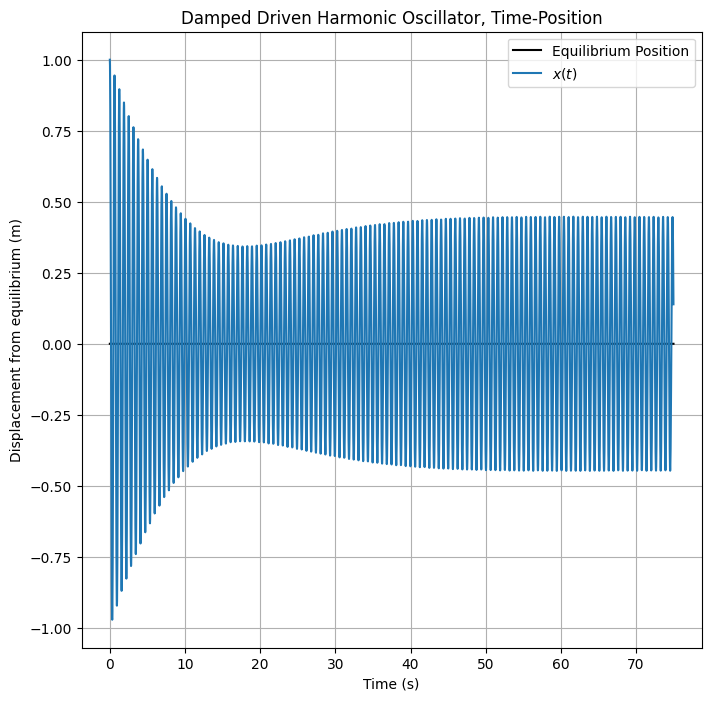

In [50]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(DDO_df['t'],np.zeros(t.shape),color="black",label="Equilibrium Position")
ax.plot(DDO_df['t'],DDO_df['x'],label=r"$x(t)$")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement from equilibrium (m)")
ax.set_title("Damped Driven Harmonic Oscillator, Time-Position")
ax.grid()
ax.legend()
plt.show()

We see that the amplitude of the oscillation decreases very quickly and then stabilizes to just under half of the initial amplitude.

We now check $\omega = 100 >> 10 = \omega_0$.

In [56]:
omega = 100
fargs_1 = (omega,f_0,beta,omega_0)
t,x,v = RK2O_t_dep(x_0,v_0,t_0,t_f,dt,DampedDrivenOscillatorAcc,fargs_1)
DDO_df = pd.DataFrame({'t':t,'x':x,'v':v})

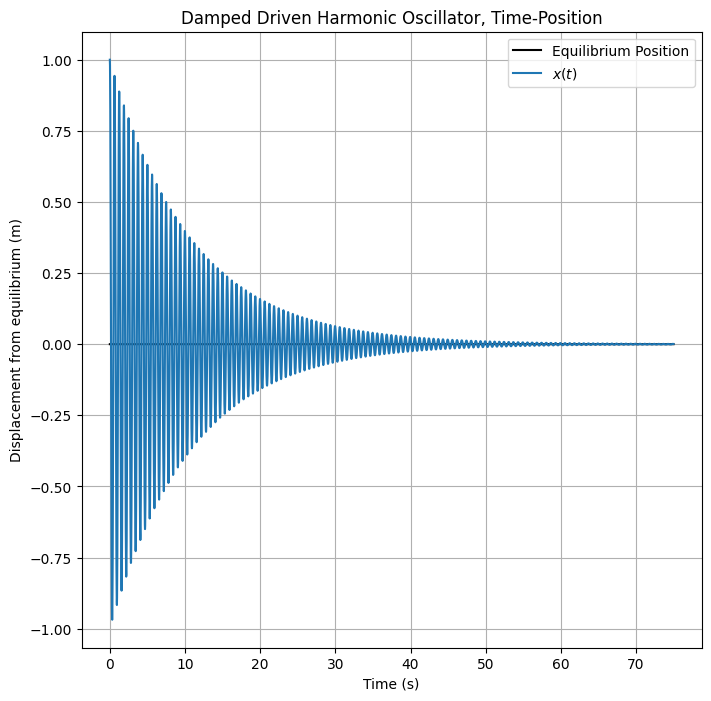

In [57]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(DDO_df['t'],np.zeros(t.shape),color="black",label="Equilibrium Position")
ax.plot(DDO_df['t'],DDO_df['x'],label=r"$x(t)$")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement from equilibrium (m)")
ax.set_title("Damped Driven Harmonic Oscillator, Time-Position")
ax.grid()
ax.legend()
plt.show()

We see that the amplitude of the oscillation very quickly decreases to a negligible amount.

### 4c.)

Sweep the driving frequency $\omega$ at a fixed amplitude and store the amplitude of the steady-state solution. Plot the amplitude as a function of the driving frequency $\omega$. Describe the behavior of the amplitude as a function of the driving frequency.

In [63]:
domega = 0.25 #we take this much space between omega values 
omega = np.arange(0,20,domega) #make the array
amp_val = np.zeros(omega.shape) #initialize an array for amplitudes of the same size as omega.
t_f = 200
for i in range(0,len(omega)):
    fargs_i = (omega[i],f_0,beta,omega_0) # take the i-th value of omega
    t,x,v = RK2O_t_dep(x_0,v_0,t_0,t_f,dt,DampedDrivenOscillatorAcc,fargs_i) #call our function
    amp_val[i] = np.max(x[8000:]) #make the i-th value of the amplitude the maximum position after 160 seconds


C:\Users\Matrim\AppData\Local\Temp\ipykernel_11484\2608952796.py:1: RuntimeWarning: divide by zero encountered in divide
  func_aray = (1/18) * np.abs(1/(omega-10))


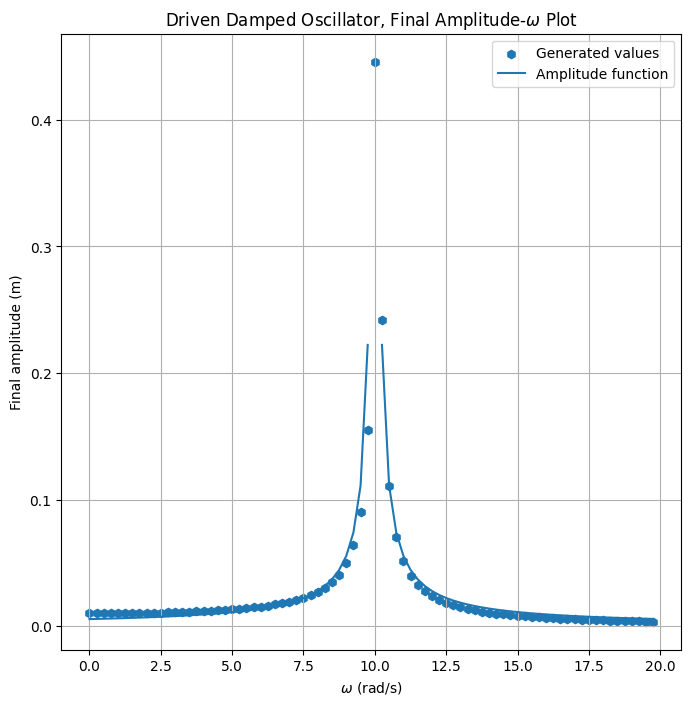

In [79]:
func_aray = (1/18) * np.abs(1/(omega-10))
fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.scatter(omega,amp_val, label="Generated values",marker="h")
ax.plot(omega,func_aray,label="Amplitude function")
ax.set_xlabel(r"$\omega$ (rad/s)")
ax.set_ylabel(r"Final amplitude (m)")
ax.set_title(r"Driven Damped Oscillator, Final Amplitude-$\omega$ Plot")
ax.grid()
ax.legend()

plt.show()

We fit the equation $A_{fin}(\omega) = \frac{1}{16(\omega - \omega_0)}$ to our created data, and it seems to fit decently.

It has an inverse correlation with omega values far from $\omega_0$..